# Reading recommendation - EDA and problem framing

This notebook looks at the data shape, sparsity, and whether the interaction log has enough signal to learn reading order. The final task choice used in `model_training.ipynb` is explained in section 5.


In [ ]:
# Setup: paths relative to this notebook
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# figures
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

DATA = Path(".")
chapters = pd.read_csv(DATA / "chapters.csv")
interactions = pd.read_csv(DATA / "interactions.csv")

print("chapters:", chapters.shape, "| interactions:", interactions.shape)

chapters: (50000, 6) | interactions: (1000000, 3)


## 1. Catalog (`chapters.csv`)

Sample rows, dtypes, books/chapter counts.


In [ ]:
display(chapters.head())
print(chapters.dtypes)

books_in_catalog = chapters["book_id"].nunique()
cpb = chapters.groupby("book_id").size()

summary_catalog = pd.Series({
    "rows (chapters)": len(chapters),
    "unique books": books_in_catalog,
    "chapters per book (median)": cpb.median(),
    "chapters per book (mean)": round(cpb.mean(), 2),
    "chapters per book (max)": cpb.max(),
    "books with only 1 chapter": int((cpb == 1).sum()),
    "books with >= 5 chapters": int((cpb >= 5).sum()),
})
display(summary_catalog)

# Tag richness (cold start / content signals)
chapters["n_tags"] = chapters["tags"].fillna("").apply(lambda s: len([t for t in s.split("|") if t]))
print("Tags: non-empty rows", round((chapters["tags"].notna() & (chapters["tags"] != "")).mean(), 3))
print("Median tag count per chapter:", chapters["n_tags"].median())

,chapter_id,chapter_sequence_no,book_id,author_id,published_date,tags
0,2812946,1,139726,66847,1990-03-22,Fantasy|Horror
1,4330764,2,139726,66847,1990-04-09,Fantasy|Young Adult|Literary Fiction
2,2664499,3,139726,66847,1990-04-07,Fantasy
3,2260666,4,139726,66847,1990-05-18,Literary Fiction|Fantasy
4,6069976,1,191772,62262,2008-07-30,Horror|Young Adult|Romance|Graphic Novel


chapter_id              int64
chapter_sequence_no     int64
book_id                 int64
author_id               int64
published_date         object
tags                   object
dtype: object


rows (chapters)               50000.00
unique books                   9575.00
chapters per book (median)        4.00
chapters per book (mean)          5.22
chapters per book (max)          20.00
books with only 1 chapter       944.00
books with >= 5 chapters       4216.00
dtype: float64

Tags: non-empty rows 1.0
Median tag count per chapter: 3.0


## 2. Interactions (`interactions.csv`)

No timestamp; sanity on users/chapters vs catalog.


In [ ]:
display(interactions.head())

catalog_ids = set(chapters["chapter_id"])
ix_ids = set(interactions["chapter_id"])

summary_ix = pd.Series({
    "interaction rows": len(interactions),
    "unique users": interactions["user_id"].nunique(),
    "unique chapters touched": interactions["chapter_id"].nunique(),
    "unique books touched": interactions["book_id"].nunique(),
    "chapter ids not in chapters.csv": len(ix_ids - catalog_ids),
    "duplicate (user, chapter) pairs": int(interactions.duplicated(subset=["user_id", "chapter_id"]).sum()),
})
display(summary_ix)

# Sanity: book_id in interactions should match chapter's book (spot-check)
merged_chk = interactions.merge(
    chapters[["chapter_id", "book_id"]].rename(columns={"book_id": "book_id_cat"}),
    on="chapter_id",
    how="left",
)
mismatch = (merged_chk["book_id"] != merged_chk["book_id_cat"]).sum()
print("Rows where interaction book_id != chapter's book_id in catalog:", int(mismatch))

,user_id,chapter_id,book_id
0,user_2378720,5894067,444295
1,user_2321122,2532511,785684
2,user_2335775,6777764,999595
3,user_7906001,7366896,748410
4,user_9981689,7853186,418083


interaction rows                   1000000
unique users                        149803
unique chapters touched              49998
unique books touched                  9575
chapter ids not in chapters.csv          0
duplicate (user, chapter) pairs          0
dtype: int64

Rows where interaction book_id != chapter's book_id in catalog: 0


### 2.1 User activity

Interactions per user; books touched per user.


interactions per user (median)           6.000
interactions per user (mean)             6.675
interactions per user (max)             20.000
books per user (median)                  6.000
books per user (mean)                    6.672
books per user (max)                    20.000
users with <= 3 interactions (share)     0.099
users with only 1 book (share)           0.008
dtype: float64

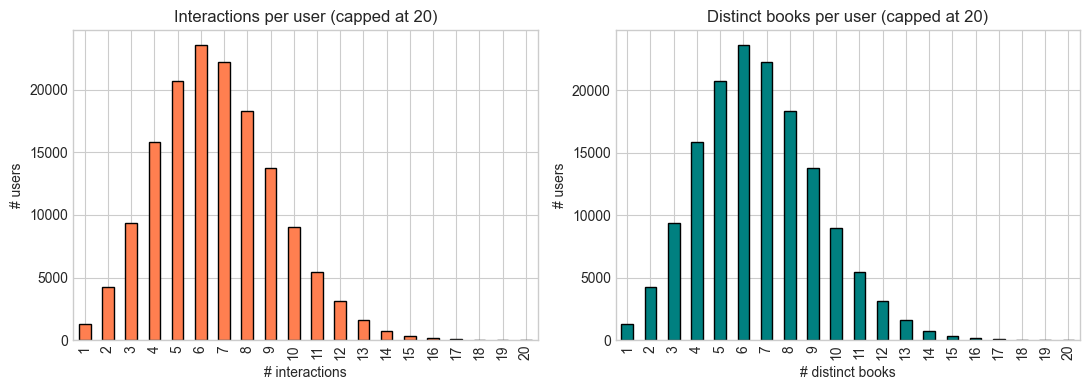

In [ ]:
upu = interactions.groupby("user_id").size()
books_per_user = interactions.groupby("user_id")["book_id"].nunique()

act = pd.Series({
    "interactions per user (median)": upu.median(),
    "interactions per user (mean)": round(upu.mean(), 3),
    "interactions per user (max)": upu.max(),
    "books per user (median)": books_per_user.median(),
    "books per user (mean)": round(books_per_user.mean(), 3),
    "books per user (max)": books_per_user.max(),
    "users with <= 3 interactions (share)": round((upu <= 3).mean(), 3),
    "users with only 1 book (share)": round((books_per_user == 1).mean(), 3),
})
display(act)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
upu.value_counts().sort_index().head(20).plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("Interactions per user (capped at 20)")
axes[0].set_xlabel("# interactions")
axes[0].set_ylabel("# users")

books_per_user.value_counts().sort_index().head(20).plot(kind="bar", ax=axes[1], color="teal", edgecolor="black")
axes[1].set_title("Distinct books per user (capped at 20)")
axes[1].set_xlabel("# distinct books")
axes[1].set_ylabel("# users")
plt.tight_layout()
plt.show()

## 3. Within-book depth

To learn a chapter-by-chapter reading sequence, we would need many `(user, book)` pairs where the same user has interacted with multiple different chapters from the same book. This section checks that using `chapter_sequence_no` from the catalog.


In [ ]:
ix_meta = interactions.merge(
    chapters[["chapter_id", "book_id", "chapter_sequence_no"]],
    on=["chapter_id", "book_id"],
    how="left",
)
missing_seq = ix_meta["chapter_sequence_no"].isna().sum()
print("Rows missing chapter metadata after merge:", int(missing_seq))

ub = ix_meta.groupby(["user_id", "book_id"], sort=False).agg(
    n_distinct_chapters=("chapter_id", "nunique"),
)
vc = ub["n_distinct_chapters"].value_counts().sort_index()

display(vc.to_frame("num_user_book_pairs"))
print("\nShare of (user, book) pairs with exactly 1 chapter:", round((ub["n_distinct_chapters"] == 1).mean(), 6))
print("Pairs with >= 2 chapters:", int((ub["n_distinct_chapters"] >= 2).sum()))
print("Pairs with >= 3 chapters:", int((ub["n_distinct_chapters"] >= 3).sum()))

# Among pairs with 2 chapters: how "contiguous" are reads in sequence space?
two = ub[ub["n_distinct_chapters"] == 2].index
sub = ix_meta.set_index(["user_id", "book_id"]).loc[list(two)].reset_index()
span_stats = sub.groupby(["user_id", "book_id"]).agg(
    min_seq=("chapter_sequence_no", "min"),
    max_seq=("chapter_sequence_no", "max"),
)
span_stats["span_len"] = span_stats["max_seq"] - span_stats["min_seq"] + 1
span_stats["density"] = 2 / span_stats["span_len"]
print("\nAmong the rare 2-chapter pairs: contiguous (density==1) share:", round((span_stats["density"] == 1).mean(), 3))

Rows missing chapter metadata after merge: 0


,num_user_book_pairs
n_distinct_chapters,
1,999040
2,480



Share of (user, book) pairs with exactly 1 chapter: 0.99952
Pairs with >= 2 chapters: 480
Pairs with >= 3 chapters: 0

Among the rare 2-chapter pairs: contiguous (density==1) share: 0.219


**Takeaway:** this log is much wider than it is deep. Almost all `(user, book)` pairs contain only one chapter, 480 pairs contain two chapters, and none contain three or more. So there is not enough observed in-book progression to train a real sequence model from interactions. Here, `chapter_sequence_no` is useful as metadata, but not as true supervision from user behavior.


## 4. Sparsity & popularity

User×chapter density; long tail of chapter popularity (one histogram).


n_users                             1.498030e+05
n_chapters_(interacted)             4.999800e+04
upper_bound_user_x_chapter_pairs    7.489850e+09
observed_pairs                      1.000000e+06
density_(observed/possible)         1.335140e-04
dtype: float64

Interactions per chapter — median: 11.0 | mean: 20.0 | max: 264
Share of chapters with exactly 1 interaction: 0.0002


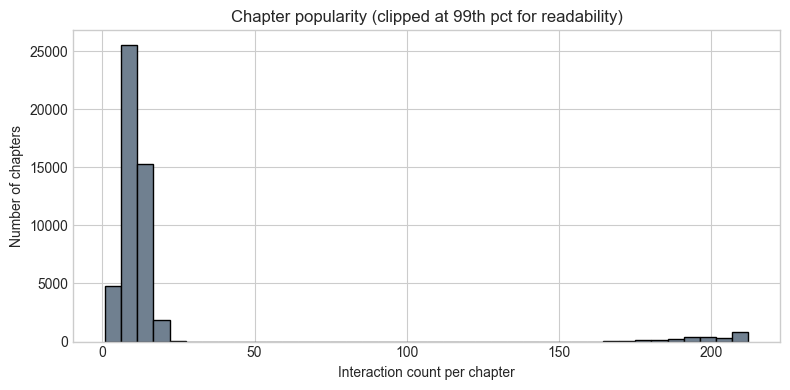

In [ ]:
n_users = interactions["user_id"].nunique()
n_chapters_ix = interactions["chapter_id"].nunique()
possible = n_users * n_chapters_ix
observed = len(interactions)

sparsity = pd.Series({
    "n_users": n_users,
    "n_chapters_(interacted)": n_chapters_ix,
    "upper_bound_user_x_chapter_pairs": possible,
    "observed_pairs": observed,
    "density_(observed/possible)": round(observed / possible, 10),
})
display(sparsity)

ipc = interactions.groupby("chapter_id").size()
print("Interactions per chapter — median:", ipc.median(), "| mean:", round(ipc.mean(), 2), "| max:", ipc.max())
print("Share of chapters with exactly 1 interaction:", round((ipc == 1).mean(), 4))

fig, ax = plt.subplots(figsize=(8, 4))
ipc.clip(upper=ipc.quantile(0.99)).hist(bins=40, ax=ax, color="slategray", edgecolor="black")
ax.set_title("Chapter popularity (clipped at 99th pct for readability)")
ax.set_xlabel("Interaction count per chapter")
ax.set_ylabel("Number of chapters")
plt.tight_layout()
plt.show()

## 5. Final problem statement

**Task:** recommend top-N chapters using implicit feedback. I am not treating this as a true next-item or next-in-time task because there are no timestamps and there is very little usable within-book sequence signal.

**Why this framing makes sense:**

| Observation | What it means |
|---------------|-------------|
| About **99.96%** of `(user, book)` pairs contain only one chapter | A learned sequential model is not well supported by the interaction data |
| The matrix is extremely sparse | Popularity and weak collaborative filtering are realistic baselines |
| There is no timestamp | Leave-one-out per user is only a practical offline proxy |

**Evaluation (same as `model_training.ipynb`):** hold out one chapter per eligible user, train on the rest, then rank the held-out chapter against all catalog chapters that are not in that user's train set. Metrics: **Hit@K**, **MRR**, and **NDCG@K**.
